In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib
import os

In [13]:
df = pd.read_csv('../data/processed/steam_cleaned.csv')
print(f"Dados carregados: {df.shape}")

Dados carregados: (19371, 396)


In [14]:
df = df.dropna(subset=['total_ratings'])
df['popularity_tier'] = pd.qcut(df['total_ratings'], q=4, labels=['Baixa', 'Média', 'Alta', 'Hit'])

# Criar a nossa classe binária
df['is_hit'] = (df['popularity_tier'] == 'Hit').astype(int)

print("Distribuição da classe 'is_hit':")
print(df['is_hit'].value_counts(normalize=True))

Distribuição da classe 'is_hit':
is_hit
0    0.750039
1    0.249961
Name: proportion, dtype: float64


In [15]:
features = ['is_free', 'is_multiplayer', 'price', 'average_playtime_hours', 'positive_ratings']
target = 'is_hit'

X = df[features]
y = df[target]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
y_pred = model_dt.predict(X_test)
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))


--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2906
           1       0.99      0.92      0.96       969

    accuracy                           0.98      3875
   macro avg       0.98      0.96      0.97      3875
weighted avg       0.98      0.98      0.98      3875



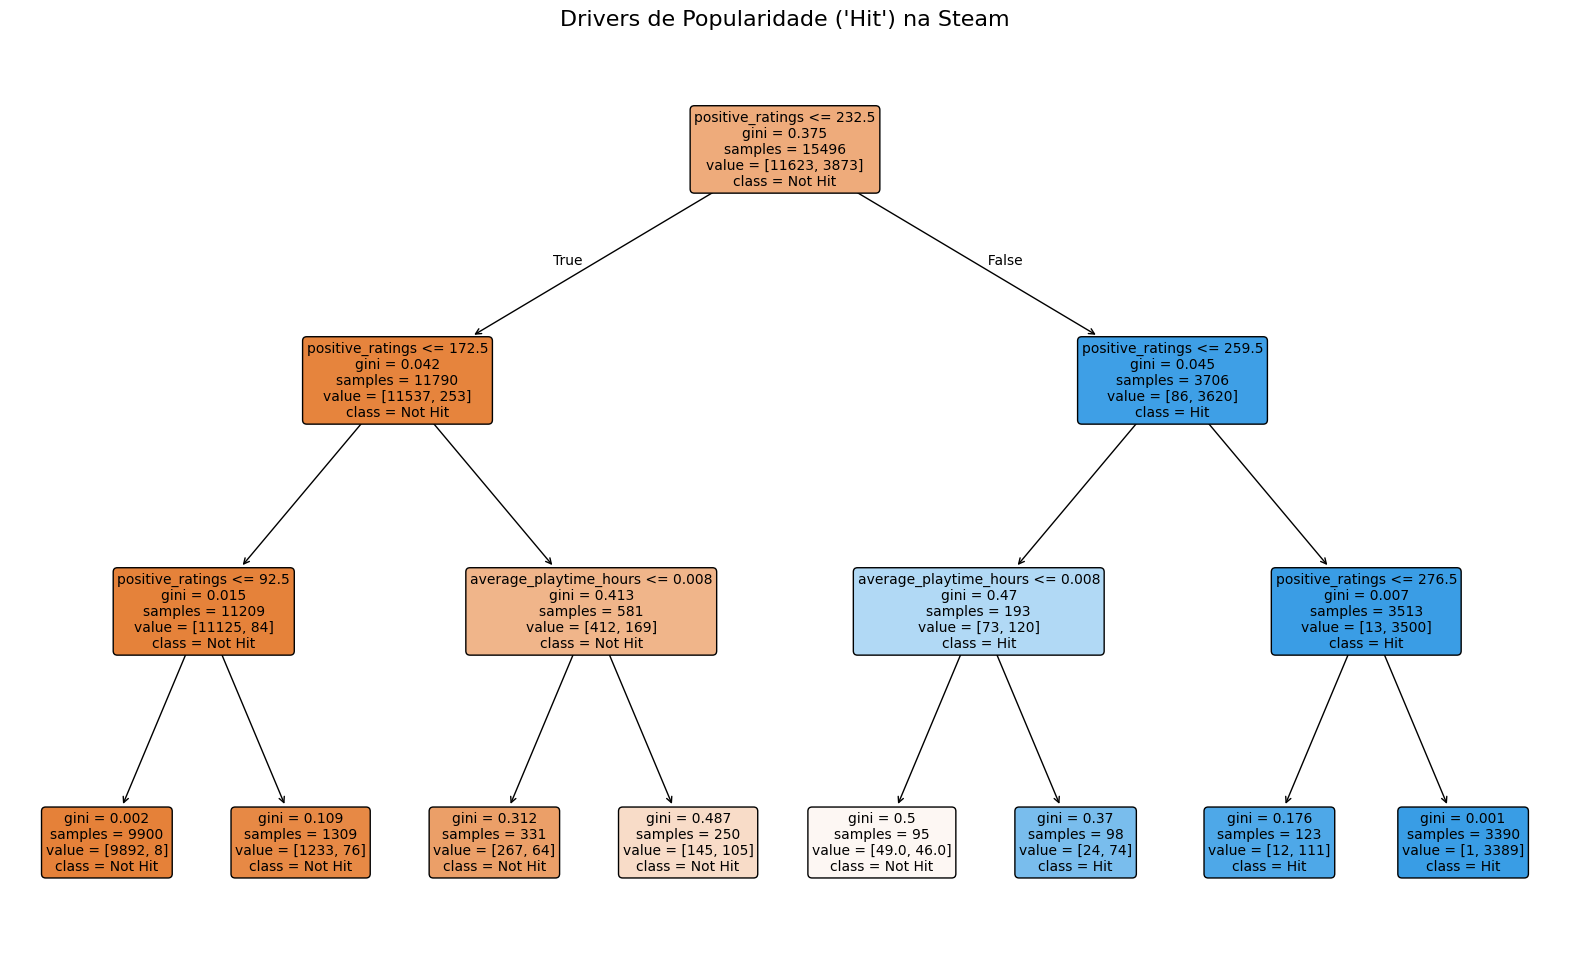

In [19]:
plt.figure(figsize=(20, 12))
plot_tree(
    model_dt,
    feature_names=features,
    class_names=['Not Hit', 'Hit'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Drivers de Popularidade ('Hit') na Steam", fontsize=16)
plt.show()

In [20]:
os.makedirs('../models', exist_ok=True)

joblib.dump(model_dt, '../models/modelo_classificacao_hit.joblib')

print("Modelo de Classificação salvo em ../models/")

Modelo de Classificação salvo em ../models/
